1. Téléchargement des bibliothèques

In [ ]:
# -*- coding: utf-8 *-

#Vérification de l'environnement de travail
import sys
print(sys.executable)

# Chargement des bibliothèques
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, classification_report


/opt/anaconda3/bin/python


2. Chargement des données et séparations des variables explicatives de la variable cible

In [69]:
#Import des jeux de données train, test et validation

chemin="/Users/antoine/Documents/GitHub/Liora_Covid/csv/"

train=pd.read_csv(chemin+"train_features.csv", sep=",")
test=pd.read_csv(chemin+"test_features.csv", sep=",")
val=pd.read_csv(chemin+"validation_features.csv", sep=",")

display(train.head())

display(test.head())

display(val)

print(val.info())

classe_names=train["classe"].unique()

#Extraction des données explicatives et des classes

X_train, y_train = train.drop(columns=["filename", "classe"]), train["classe"]

X_test, y_test = test.drop(columns=["filename", "classe"]), test["classe"]

X_val, y_val = val.drop(columns=["filename", "classe"]), test["classe"]

print(f"Dimension de X_train {X_train.shape}, de X_test {X_test.shape} et de X_val {X_val.shape}.")
print(f"Dimension de y_train {y_train.shape}, de y_test {y_test.shape} et de y_val {y_val.shape}.")


,filename,classe,lum_interieur_masque,lum_exterieur_masque,surface_masque,variance_laplacien
0,COVID-1.png,COVID,144.7131,10.9031,0.234125,1779.5722
1,COVID-1000.png,COVID,139.1298,10.8428,0.245299,1697.4233
2,COVID-1001.png,COVID,139.1083,10.9089,0.148320,1661.2817
3,COVID-1003.png,COVID,139.5053,10.8849,0.317368,2349.8774
4,COVID-1004.png,COVID,137.8372,10.9414,0.130647,1228.5824


,filename,classe,lum_interieur_masque,lum_exterieur_masque,surface_masque,variance_laplacien
0,COVID-1002.png,COVID,138.8807,10.7731,0.424201,2473.2551
1,COVID-103.png,COVID,136.3334,10.8689,0.307122,2242.3158
2,COVID-1031.png,COVID,142.1247,10.9505,0.207895,1721.8334
3,COVID-1044.png,COVID,141.4175,10.8874,0.238968,1830.1106
4,COVID-1057.png,COVID,140.9709,10.9149,0.151889,1962.9220


,filename,classe,lum_interieur_masque,lum_exterieur_masque,surface_masque,variance_laplacien
0,COVID-10.png,COVID,140.9980,10.8718,0.262670,2205.6286
1,COVID-1009.png,COVID,142.5276,10.8780,0.217593,1664.2018
2,COVID-1013.png,COVID,136.7686,10.8848,0.251082,1580.5716
3,COVID-1016.png,COVID,141.7234,10.9008,0.242369,1930.6751
4,COVID-1018.png,COVID,143.9314,10.9175,0.217816,2053.5038
...,...,...,...,...,...,...
2078,Viral Pneumonia-930.png,Viral Pneumonia,137.2817,10.8447,0.281641,2098.0273
2079,Viral Pneumonia-951.png,Viral Pneumonia,140.9447,10.8399,0.262290,2240.1258
2080,Viral Pneumonia-977.png,Viral Pneumonia,140.0778,10.8271,0.284370,1775.8979
2081,Viral Pneumonia-978.png,Viral Pneumonia,138.9641,10.8736,0.296540,2358.7113


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2083 entries, 0 to 2082
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   filename              2083 non-null   object 
 1   classe                2083 non-null   object 
 2   lum_interieur_masque  2083 non-null   float64
 3   lum_exterieur_masque  2083 non-null   float64
 4   surface_masque        2083 non-null   float64
 5   variance_laplacien    2083 non-null   float64
dtypes: float64(4), object(2)
memory usage: 97.8+ KB
None
Dimension de X_train (16668, 4), de X_test (2084, 4) et de X_val (2083, 4).
Dimension de y_train (16668,), de y_test (2084,) et de y_val (2084,).


3. Scaling

In [25]:
scaler=StandardScaler()
X_train_scaled=pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled=pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
X_val_scaled=pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)

print(X_train_scaled.head())
print(X_test_scaled.head())
print(X_val_scaled.head())

   lum_interieur_masque  lum_exterieur_masque  surface_masque  \
0              1.646255              0.498036       -0.073561   
1             -0.504330             -0.779855        0.109476   
2             -0.512611              0.620951       -1.479099   
3             -0.359694              0.112337        1.290009   
4             -1.002216              1.309698       -1.768593   

   variance_laplacien  
0           -0.619641  
1           -0.832769  
2           -0.926535  
3            0.859964  
4           -2.049134  
   lum_interieur_masque  lum_exterieur_masque  surface_masque  \
0             -0.600279             -2.256954        3.039998   
1             -1.581452             -0.226738        1.122174   
2              0.649251              1.502548       -0.503224   
3              0.376850              0.165318        0.005770   
4              0.204828              0.748104       -1.420636   

   variance_laplacien  
0            1.180056  
1            0.580905  
2 

4. Modélisation et entraînement d'un modèle des K plus proches voisins

In [26]:
modelknn=KNeighborsClassifier(n_neighbors=5, weights="uniform", metric="minkowski")

modelknn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


5. Évaluation du modèle

                 precision    recall  f1-score   support

          COVID       0.26      0.20      0.23       337
   Lung_Opacity       0.49      0.51      0.50       599
         Normal       0.65      0.72      0.68      1014
Viral Pneumonia       0.46      0.26      0.33       134

       accuracy                           0.55      2084
      macro avg       0.47      0.42      0.44      2084
   weighted avg       0.53      0.55      0.53      2084



Classes prédites,COVID,Lung_Opacity,Normal,Viral Pneumonia
Classes réelles,,,,
COVID,67,114,152,4
Lung_Opacity,87,307,190,15
Normal,93,168,731,22
Viral Pneumonia,7,37,55,35


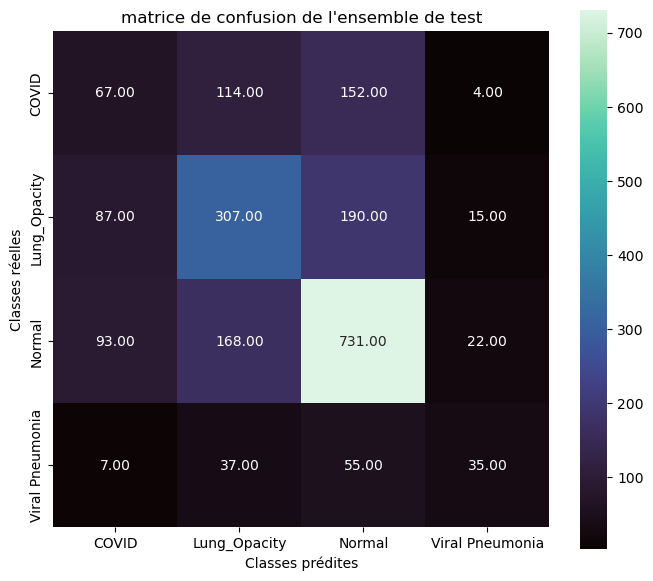

In [43]:
#Évaluation sur l'ensemble de test

y_test_pred=modelknn.predict(X_test_scaled)

cm_test=pd.crosstab(y_test, y_test_pred, colnames=["Classes prédites"], rownames=["Classes réelles"])

print(classification_report(y_test, y_test_pred))

display(cm_test)

figure_1=plt.figure(figsize=(8,7))

sns.heatmap(cm_test, annot=True, square=True, fmt=".2f", cmap="mako")

plt.title("matrice de confusion de l'ensemble de test")

plt.show()


In [44]:
#Évaluation sur l'ensemble de test

y_val_pred=modelknn.predict(X_val_scaled)

cm_val=pd.crosstab(y_val, y_val_pred, colnames=["Classes prédites"], rownames=["Classes réelles"])

print(classification_report(y_val, y_val_pred))

display(cm_val)

figure_2=plt.figure(figsize=(8,7))

sns.heatmap(cm_val, annot=True, square=True, fmt=".2f", cmap="rocket")

plt.title("matrice de confusion de l'ensemble de validation")

plt.show()

ValueError: Length of values (2083) does not match length of index (2084)

6. Amélioration du modèle

In [52]:
#Initialisation de la grille et de ses paramètres puis entraînement sur les données d'entraînement

parametres={"n_neighbors":np.arange(3,15), "weights":["uniform", "distance"], "metric":["euclidian", "minkowski", "manhattan", "chebyshev"]}

modelKNN=KNeighborsClassifier()

grille=GridSearchCV(modelKNN, parametres, scoring="f1_macro", cv=5)
resultats_grille=grille.fit(X_train_scaled, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
120 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 471, in _validate_para

In [54]:
#Résultats de la grille

print("Paramètres les plus performants : ", resultats_grille.best_params_)

print(f"Meilleur f1-score : {grille.best_score_}")

Paramètres les plus performants :  {'metric': 'chebyshev', 'n_neighbors': np.int64(14), 'weights': 'uniform'}
Meilleur f1-score : 0.4490013551533007


7. Initialisation d'un nouveau modèle à partir des résultats de la validation croisée

In [56]:

#Paramétrage et entraînement du nouveau modèle
modelKNN_best=KNeighborsClassifier(n_neighbors=resultats_grille.best_params_["n_neighbors"], weights=resultats_grille.best_params_["weights"], metric=resultats_grille.best_params_["metric"])
modelKNN_fitted=modelKNN_best.fit(X_train_scaled, y_train)


8. Évaluation du nouveau modèle

                 precision    recall  f1-score   support

          COVID       0.38      0.12      0.18       337
   Lung_Opacity       0.54      0.54      0.54       599
         Normal       0.65      0.84      0.73      1014
Viral Pneumonia       0.53      0.31      0.39       134

       accuracy                           0.60      2084
      macro avg       0.53      0.45      0.46      2084
   weighted avg       0.57      0.60      0.57      2084



Classes prédites,COVID,Lung_Opacity,Normal,Viral Pneumonia
Classes réelles,,,,
COVID,41,125,166,5
Lung_Opacity,30,325,225,19
Normal,31,120,849,14
Viral Pneumonia,6,29,57,42


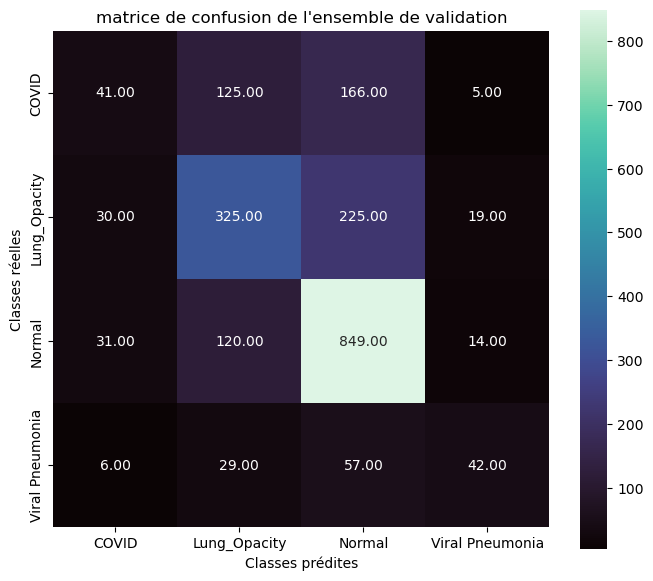

In [57]:
#Sur l'ensemble de test

y_test_best_pred=modelKNN_fitted.predict(X_test_scaled)

cm_test_best=pd.crosstab(y_test, y_test_best_pred, colnames=["Classes prédites"], rownames=["Classes réelles"])

print(classification_report(y_test, y_test_best_pred))

display(cm_test_best)

figure_3=plt.figure(figsize=(8,7))

sns.heatmap(cm_test_best, annot=True, square=True, fmt=".2f", cmap="mako")

plt.title("matrice de confusion de l'ensemble de validation")

plt.show()

In [58]:
#Sur l'ensemble de validation

y_val_best_pred=modelKNN_fitted.predict(X_val_scaled)

cm_val_best=pd.crosstab(y_test, y_val_best_pred, colnames=["Classes prédites"], rownames=["Classes réelles"])

print(classification_report(y_val, y_val_best_pred))

display(cm_val_best)

figure_3=plt.figure(figsize=(8,7))

sns.heatmap(cm_val_best, annot=True, square=True, fmt=".2f", cmap="rocket")

plt.title("matrice de confusion de l'ensemble de validation")

plt.show()

ValueError: Length of values (2083) does not match length of index (2084)